In [ ]:
# 1.0. 필수 라이브러리 설치
!pip install xgboost
!pip install optuna

# 1.1. Google Drive 마운트
from google.colab import drive
drive.mount('/content/drive')

# 1.2. 프로젝트 경로 설정
import sys
import os

# 프로젝트의 기본 경로 설정
base_project_path = '/content/drive/MyDrive/imbalanced loss project'

# 데이터, 소스 코드, 결과 폴더 경로 정의
data_path = os.path.join(base_project_path, 'data')
src_path = os.path.join(base_project_path, 'src')
results_path = os.path.join(base_project_path, 'f1-score/alpha_tuning')

# src 폴더를 시스템 경로에 추가하여 모듈을 임포트할 수 있도록 설정
if src_path not in sys.path:
    sys.path.append(src_path)

# 결과 폴더가 없으면 생성
os.makedirs(results_path, exist_ok=True)

print(f"데이터 경로: {data_path}")
print(f"소스 코드 경로: {src_path}")
print(f"결과 저장 경로: {results_path}")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
데이터 경로: /content/drive/MyDrive/imbalanced loss project/data
소스 코드 경로: /content/drive/MyDrive/imbalanced loss project/src
결과 저장 경로: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning


In [ ]:
# 1.3. 라이브러리 및 커스텀 모듈 임포트
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
import json
import optuna
import xgboost as xgb
import importlib

# 직접 구현한 모듈 임포트
import data_handler
import custom_losses
import evaluation
import optuna_tuner_xgb_linear

# [수정] 모든 커스텀 모듈을 강제로 다시 로드합니다.
importlib.reload(data_handler)
importlib.reload(custom_losses)
importlib.reload(evaluation)
importlib.reload(optuna_tuner_xgb_linear)

print("모듈 임포트 완료 (모든 모듈 강제 새로고침 적용).")

모듈 임포트 완료 (모든 모듈 강제 새로고침 적용).


In [ ]:
# 2.1. 실험 대상 데이터셋 정의
datasets_to_run = [
    'credit_card_fraud',
    'aps_failure',
    'bank_marketing',
    'telco_churn',
    'german_credit',
    'secom',
    'credit_card_default',
    'glass',
    'steel_faults',
    'yeast',
    'page_blocks'
    #'covertype'
]

# 필요한 라이브러리 임포트
from scipy.special import expit, softmax
import pandas as pd
import xgboost as xgb

print("실험 구성 완료.")
print(f"실행할 데이터셋: {datasets_to_run}")

실험 구성 완료.
실행할 데이터셋: ['credit_card_fraud', 'aps_failure', 'bank_marketing', 'telco_churn', 'german_credit', 'secom', 'credit_card_default', 'glass', 'steel_faults', 'yeast', 'page_blocks']


In [ ]:
'''
# 4번셀: XGBoost gblinear (선형 모델) + 커스텀 손실 함수 전체 최적화

import optuna_tuner_xgb_linear  # 새로 만든 튜너 임포트
import pandas as pd
import numpy as np
from scipy.special import expit, softmax

all_results = []
optimized_params = {}

# Optuna 설정
OPTUNA_CONFIG = {
    'n_trials': 50,        # 60회 시행
    'cv_folds': 3,         # 3-fold CV
    'metric': 'f1_macro',
}

for dataset_name in datasets_to_run:
    print(f"\n{'='*80}")
    print(f"Processing Dataset: {dataset_name}")
    print(f"{'='*80}")

    X_train, X_test, y_train, y_test = data_handler.load_dataset(
        dataset_name=dataset_name, base_data_path=data_path, random_state=42
    )

    unique_classes = y_train.unique()
    is_multiclass = len(unique_classes) > 2
    if is_multiclass:
        n_classes = int(y_train.max() + 1)
    else:
        n_classes = len(unique_classes)

    print(f"Data loaded. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print(f"Number of classes: {n_classes}. Multi-class problem: {is_multiclass}")

    # 데이터를 numpy 배열로 변환
    if hasattr(X_train, 'values'):
        X_train_np = X_train.values
        X_test_np = X_test.values
    else:
        X_train_np = X_train
        X_test_np = X_test

    # 손실 함수 리스트 (모든 커스텀 손실 함수 지원)
    loss_names = [
        'standard_ce',
        'weighted_ce_inv',
        'weighted_ce_inv_sqrt',
        'power_scaled_inv_ce',
        'class_balanced_ce',
        'focal_loss',
        'adaptive_ce',
        'power_scaled_adaptive_ce',
        'rho_power_scaled_adaptive_ce',
        'rho_power_scaled_inv_ce'
    ]

    for loss_name in loss_names:
        print(f"\n{'-'*60}")
        print(f"Optimizing: {loss_name}")
        print(f"{'-'*60}")

        # Optuna 튜너 생성 (XGBoost gblinear 용)
        if loss_name == 'focal_loss':
            n_trials_for_loss = OPTUNA_CONFIG['n_trials'] * 2
        elif loss_name == 'rho_power_scaled_adaptive_ce':
            n_trials_for_loss = OPTUNA_CONFIG['n_trials'] * 2
        elif loss_name == 'rho_power_scaled_inv_ce':
            n_trials_for_loss = OPTUNA_CONFIG['n_trials'] * 2
        else :
            n_trials_for_loss = OPTUNA_CONFIG['n_trials']

        tuner = optuna_tuner_xgb_linear.OptunaHyperparameterTuner(
            n_trials=n_trials_for_loss,
            cv_folds=OPTUNA_CONFIG['cv_folds'],
            random_state=42,
            direction='maximize',
            metric=OPTUNA_CONFIG['metric']
        )

        # 하이퍼파라미터 최적화
        try:
            best_params = tuner.optimize(
                X_train_np, y_train,
                loss_name=loss_name,
                show_progress_bar=True
            )

            # 최적 파라미터 저장
            param_key = f"{dataset_name}_{loss_name}"
            optimized_params[param_key] = {
                'params': best_params,
                'score': tuner.best_score
            }

            # 최적 모델로 예측
            model = tuner.get_best_model(X_train_np, y_train, loss_name=loss_name)

            # 실제 클래스 개수 (모델이 학습한 클래스 수)
            if hasattr(model, 'n_classes_actual_'):
                n_classes_for_eval = model.n_classes_actual_
            else:
                n_classes_for_eval = n_classes

            # 라벨 인코더가 있으면 y_test도 변환
            if hasattr(model, 'label_encoder_'):
                y_test_encoded = model.label_encoder_.transform(y_test)
            else:
                y_test_encoded = y_test

            y_pred_raw = model.predict(X_test_np, output_margin=True)  # raw score

            # 예측값 후처리
            if is_multiclass:
                if loss_name == 'standard_ce':
                    # standard_ce는 이미 확률로 나옴
                    y_pred_proba = model.predict_proba(X_test_np)
                else:
                    # 커스텀 손실은 raw score이므로 softmax 적용
                    y_pred_proba = softmax(y_pred_raw.reshape(-1, n_classes_for_eval), axis=1)
            else:
                if loss_name == 'standard_ce':
                    # standard_ce는 이미 확률로 나옴
                    y_pred_proba = model.predict_proba(X_test_np)[:, 1]
                else:
                    # 커스텀 손실은 raw score이므로 sigmoid 적용
                    y_pred_proba = expit(y_pred_raw)

            # 평가
            eval_n_classes = n_classes_for_eval if is_multiclass else 2
            metrics = evaluation.evaluate_classification_model(
                y_true=y_test_encoded,  # 인코딩된 레이블 사용
                y_pred_proba=y_pred_proba,
                n_classes=eval_n_classes,
                model_name='xgboost_gblinear',
                loss_name=loss_name,
                dataset_name=dataset_name,
                save_path=results_path
            )
            all_results.append(metrics)

            print(f"✅ {loss_name} 완료 - F1: {metrics['F1-Score']:.4f}")

        except Exception as e:
            print(f"❌ Error optimizing {loss_name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # 중간 저장 (데이터셋마다 저장)
    temp_results_df = pd.DataFrame(all_results)
    temp_csv_path = os.path.join(results_path, f'xgb_linear_results_temp_{dataset_name}.csv')
    temp_results_df.to_csv(temp_csv_path, index=False)
    print(f"\n💾 중간 결과 저장: {temp_csv_path}")

# 최적화된 파라미터 저장
import json
params_save_path = os.path.join(results_path, 'optimized_parameters_xgb_linear.json')
with open(params_save_path, 'w') as f:
    json.dump(optimized_params, f, indent=2)
print(f"\n✅ 최적화된 파라미터가 '{params_save_path}'에 저장되었습니다.")

# 최종 결과 저장
results_df = pd.DataFrame(all_results)
results_df['PR_AUC'] = results_df['PR_AUC'].replace(['N/A', -1], np.nan)

column_order = ['Dataset', 'Model', 'Loss', 'F1-Score', 'ROC_AUC', 'PR_AUC',
                'Accuracy', 'Precision', 'Recall']
results_df = results_df[column_order]
sorted_results_df = results_df.sort_values(by=['Dataset', 'F1-Score'], ascending=[True, False])

output_csv_path = os.path.join(results_path, 'xgboost_gblinear_full_results.csv')
sorted_results_df.to_csv(output_csv_path, index=False)

print("="*80)
print("      XGBoost gblinear (선형 모델) 전체 최적화 완료")
print("="*80)
print(f"📊 전체 결과: {output_csv_path}")
print(f"⚙️ 최적 파라미터: {params_save_path}")
'''

'\n# 4번셀: XGBoost gblinear (선형 모델) + 커스텀 손실 함수 전체 최적화\n\nimport optuna_tuner_xgb_linear  # 새로 만든 튜너 임포트\nimport pandas as pd\nimport numpy as np\nfrom scipy.special import expit, softmax\n\nall_results = []\noptimized_params = {}\n\n# Optuna 설정\nOPTUNA_CONFIG = {\n    \'n_trials\': 50,        # 60회 시행\n    \'cv_folds\': 3,         # 3-fold CV\n    \'metric\': \'f1_macro\',\n}\n\nfor dataset_name in datasets_to_run:\n    print(f"\n{\'=\'*80}")\n    print(f"Processing Dataset: {dataset_name}")\n    print(f"{\'=\'*80}")\n\n    X_train, X_test, y_train, y_test = data_handler.load_dataset(\n        dataset_name=dataset_name, base_data_path=data_path, random_state=42\n    )\n\n    unique_classes = y_train.unique()\n    is_multiclass = len(unique_classes) > 2\n    if is_multiclass:\n        n_classes = int(y_train.max() + 1)\n    else:\n        n_classes = len(unique_classes)\n\n    print(f"Data loaded. Train shape: {X_train.shape}, Test shape: {X_test.shape}")\n    print(f"Number of classes:

✅ 'optimized_parameters_xgb_linear.json'에서 기본 파라미터를 로드했습니다.

Processing Dataset: credit_card_fraud


[I 2025-11-12 08:17:21,801] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


Data loaded. Train shape: (199364, 29), Test shape: (85443, 29)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 54, 'learning_rate': 0.1953290974474592, 'reg_alpha': 1.46507470760014e-07, 'reg_lambda': 5.516961396382656e-07}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 54, 'learning_rate': 0.1953290974474592, 'reg_alpha': 1.46507470760014e-07, 'reg_lambda': 5.516961396382656e-07}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:17:25,360] Trial 0 finished with value: 0.8984074941589787 and parameters: {'loss_power_alpha': 1.539397733793271}. Best is trial 0 with value: 0.8984074941589787.
[I 2025-11-12 08:17:29,005] Trial 1 finished with value: 0.9014048374579753 and parameters: {'loss_power_alpha': 2.861249941049789}. Best is trial 1 with value: 0.9014048374579753.
[I 2025-11-12 08:17:33,392] Trial 2 finished with value: 0.8901815417428808 and parameters: {'loss_power_alpha': 3.4097273752478463}. Best is trial 1 with value: 0.9014048374579753.
[I 2025-11-12 08:17:36,604] Trial 3 finished with value: 0.8964829238329702 and parameters: {'loss_power_alpha': 1.0497922331982605}. Best is trial 1 with value: 0.9014048374579753.
[I 2025-11-12 08:17:39,764] Trial 4 finished with value: 0.8980075059502425 and parameters: {'loss_power_alpha': 1.1719324390903791}. Best is trial 1 with value: 0.9014048374579753.
[I 2025-11-12 08:17:43,392] Trial 5 finished with value: 0.9007567385140282 and parameters: 

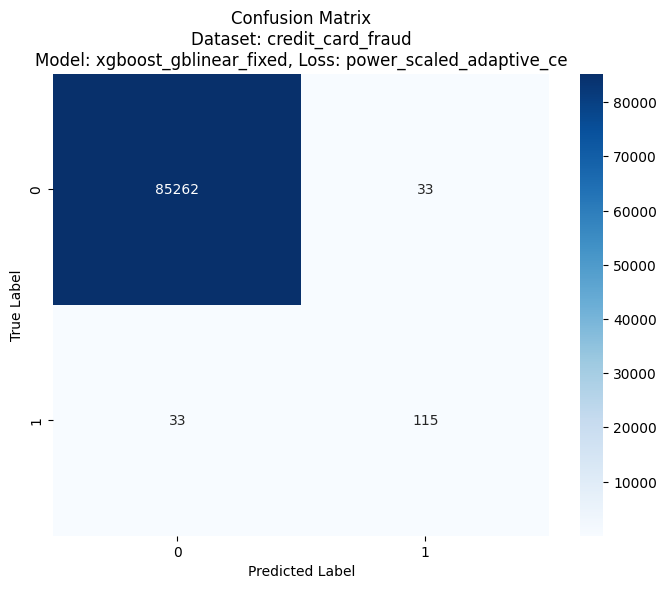

✅ power_scaled_adaptive_ce 완료 - F1: 0.7770

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_credit_card_fraud_alpha_only.csv

Processing Dataset: aps_failure


[I 2025-11-12 08:19:42,724] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


Data loaded. Train shape: (60000, 170), Test shape: (16000, 170)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 440, 'learning_rate': 0.049736540105421036, 'reg_alpha': 4.1596406653636e-06, 'reg_lambda': 1.564749040550554e-05}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 440, 'learning_rate': 0.049736540105421036, 'reg_alpha': 4.1596406653636e-06, 'reg_lambda': 1.564749040550554e-05}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:20:07,902] Trial 0 finished with value: 0.8507608853378447 and parameters: {'loss_power_alpha': 3.3587299839805107}. Best is trial 0 with value: 0.8507608853378447.
[I 2025-11-12 08:20:32,624] Trial 1 finished with value: 0.853003501039305 and parameters: {'loss_power_alpha': 2.909487179570598}. Best is trial 1 with value: 0.853003501039305.
[I 2025-11-12 08:20:53,023] Trial 2 finished with value: 0.855243916767401 and parameters: {'loss_power_alpha': 1.984105188855609}. Best is trial 2 with value: 0.855243916767401.
[I 2025-11-12 08:21:14,208] Trial 3 finished with value: 0.8555522624632116 and parameters: {'loss_power_alpha': 2.341266595838284}. Best is trial 3 with value: 0.8555522624632116.
[I 2025-11-12 08:21:33,619] Trial 4 finished with value: 0.8529039301105206 and parameters: {'loss_power_alpha': 2.8695799758240965}. Best is trial 3 with value: 0.8555522624632116.
[I 2025-11-12 08:21:55,254] Trial 5 finished with value: 0.8522473999702832 and parameters: {'los

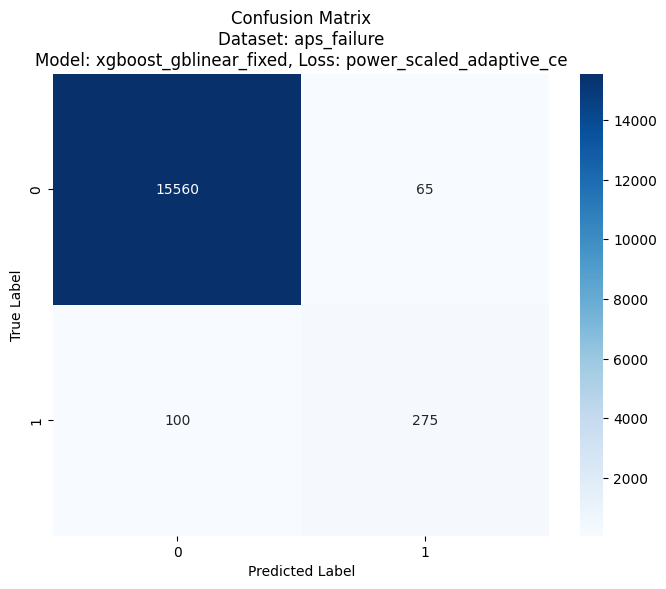

✅ power_scaled_adaptive_ce 완료 - F1: 0.7692

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_aps_failure_alpha_only.csv

Processing Dataset: bank_marketing


[I 2025-11-12 08:35:00,283] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


Data loaded. Train shape: (31647, 42), Test shape: (13564, 42)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 94, 'learning_rate': 0.14603610107937562, 'reg_alpha': 4.3426301758538093e-07, 'reg_lambda': 6.904445269589704e-06}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 94, 'learning_rate': 0.14603610107937562, 'reg_alpha': 4.3426301758538093e-07, 'reg_lambda': 6.904445269589704e-06}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:35:01,204] Trial 0 finished with value: 0.7521939513009096 and parameters: {'loss_power_alpha': 3.494214409392538}. Best is trial 0 with value: 0.7521939513009096.
[I 2025-11-12 08:35:02,095] Trial 1 finished with value: 0.7449932765051979 and parameters: {'loss_power_alpha': 2.5881889636364965}. Best is trial 0 with value: 0.7521939513009096.
[I 2025-11-12 08:35:04,067] Trial 2 finished with value: 0.7250274477475632 and parameters: {'loss_power_alpha': 1.1989736715301895}. Best is trial 0 with value: 0.7521939513009096.
[I 2025-11-12 08:35:05,855] Trial 3 finished with value: 0.7417195279974754 and parameters: {'loss_power_alpha': 2.3056609897059763}. Best is trial 0 with value: 0.7521939513009096.
[I 2025-11-12 08:35:06,736] Trial 4 finished with value: 0.7246972680860493 and parameters: {'loss_power_alpha': 1.1801964486706262}. Best is trial 0 with value: 0.7521939513009096.
[I 2025-11-12 08:35:07,629] Trial 5 finished with value: 0.7309188045027607 and parameters:

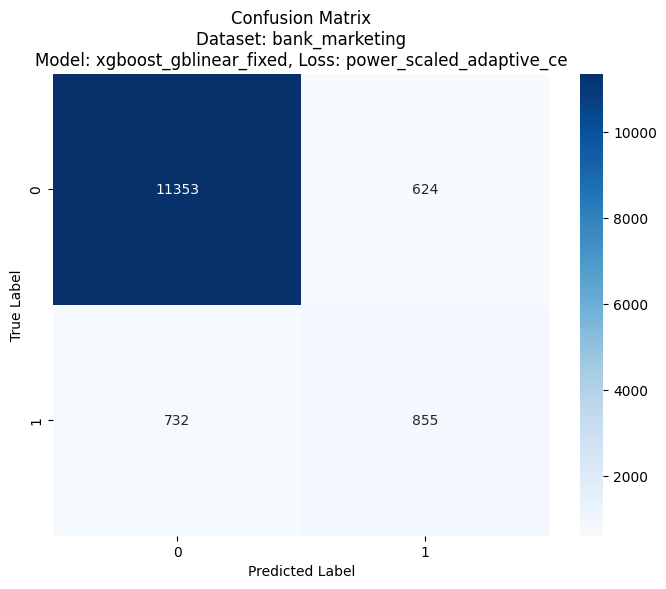

[I 2025-11-12 08:35:44,610] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


✅ power_scaled_adaptive_ce 완료 - F1: 0.5577

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_bank_marketing_alpha_only.csv

Processing Dataset: telco_churn
Data loaded. Train shape: (4930, 30), Test shape: (2113, 30)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 260, 'learning_rate': 0.26914848609424763, 'reg_alpha': 1.233646418125161e-08, 'reg_lambda': 1.1489247459559325e-05}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 260, 'learning_rate': 0.26914848609424763, 'reg_alpha': 1.233646418125161e-08, 'reg_lambda': 1.1489247459559325e-05}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:35:45,275] Trial 0 finished with value: 0.7373330563165196 and parameters: {'loss_power_alpha': 3.2183409823269513}. Best is trial 0 with value: 0.7373330563165196.
[I 2025-11-12 08:35:45,894] Trial 1 finished with value: 0.7373298626471031 and parameters: {'loss_power_alpha': 1.257484006344892}. Best is trial 0 with value: 0.7373330563165196.
[I 2025-11-12 08:35:46,493] Trial 2 finished with value: 0.7375426888797431 and parameters: {'loss_power_alpha': 2.3730536922630407}. Best is trial 2 with value: 0.7375426888797431.
[I 2025-11-12 08:35:47,103] Trial 3 finished with value: 0.7337899453445771 and parameters: {'loss_power_alpha': 1.7521616330132075}. Best is trial 2 with value: 0.7375426888797431.
[I 2025-11-12 08:35:47,693] Trial 4 finished with value: 0.7373496992381091 and parameters: {'loss_power_alpha': 2.220428096361638}. Best is trial 2 with value: 0.7375426888797431.
[I 2025-11-12 08:35:48,315] Trial 5 finished with value: 0.7381129540093975 and parameters: 

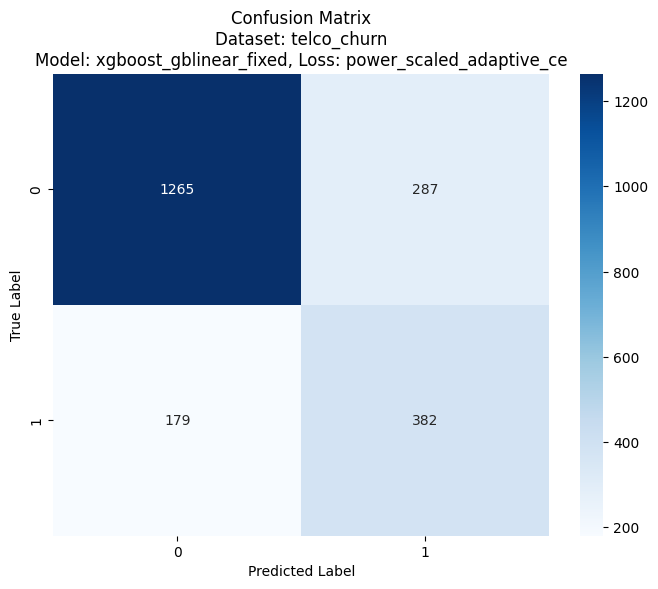

[I 2025-11-12 08:36:13,958] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


✅ power_scaled_adaptive_ce 완료 - F1: 0.6211

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_telco_churn_alpha_only.csv

Processing Dataset: german_credit
Data loaded. Train shape: (700, 48), Test shape: (300, 48)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 471, 'learning_rate': 0.03571144921717405, 'reg_alpha': 2.3537812652557128e-07, 'reg_lambda': 4.5783320995952616e-05}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 471, 'learning_rate': 0.03571144921717405, 'reg_alpha': 2.3537812652557128e-07, 'reg_lambda': 4.5783320995952616e-05}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:36:14,636] Trial 0 finished with value: 0.6735263689323746 and parameters: {'loss_power_alpha': 2.40154814517693}. Best is trial 0 with value: 0.6735263689323746.
[I 2025-11-12 08:36:15,301] Trial 1 finished with value: 0.6592266949402019 and parameters: {'loss_power_alpha': 1.192355421358423}. Best is trial 0 with value: 0.6735263689323746.
[I 2025-11-12 08:36:15,950] Trial 2 finished with value: 0.6732952584547558 and parameters: {'loss_power_alpha': 3.1731158443377825}. Best is trial 0 with value: 0.6735263689323746.
[I 2025-11-12 08:36:16,566] Trial 3 finished with value: 0.6579870259720216 and parameters: {'loss_power_alpha': 1.2039411710539663}. Best is trial 0 with value: 0.6735263689323746.
[I 2025-11-12 08:36:17,221] Trial 4 finished with value: 0.6731187657568413 and parameters: {'loss_power_alpha': 2.0946357341367197}. Best is trial 0 with value: 0.6735263689323746.
[I 2025-11-12 08:36:17,836] Trial 5 finished with value: 0.6727762557464878 and parameters: {

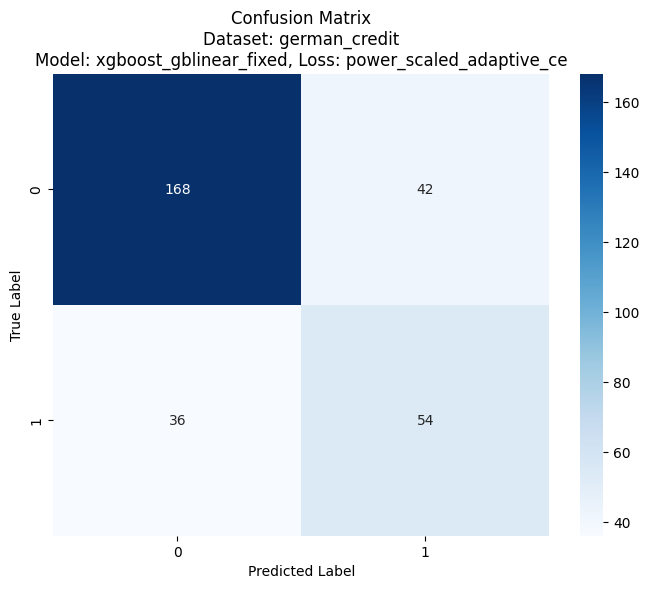

✅ power_scaled_adaptive_ce 완료 - F1: 0.5806

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_german_credit_alpha_only.csv

Processing Dataset: secom


[I 2025-11-12 08:36:45,031] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


Data loaded. Train shape: (1096, 590), Test shape: (471, 590)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 266, 'learning_rate': 0.013018812160088001, 'reg_alpha': 0.00011247427082441009, 'reg_lambda': 4.8914028997556426e-08}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 266, 'learning_rate': 0.013018812160088001, 'reg_alpha': 0.00011247427082441009, 'reg_lambda': 4.8914028997556426e-08}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:36:46,969] Trial 0 finished with value: 0.5393669186703769 and parameters: {'loss_power_alpha': 2.84254138722696}. Best is trial 0 with value: 0.5393669186703769.
[I 2025-11-12 08:36:49,644] Trial 1 finished with value: 0.5456845556163138 and parameters: {'loss_power_alpha': 2.482958466525757}. Best is trial 1 with value: 0.5456845556163138.
[I 2025-11-12 08:36:50,930] Trial 2 finished with value: 0.5475078200662816 and parameters: {'loss_power_alpha': 3.2434204550183896}. Best is trial 2 with value: 0.5475078200662816.
[I 2025-11-12 08:36:52,253] Trial 3 finished with value: 0.5463102872236728 and parameters: {'loss_power_alpha': 2.4738738545766594}. Best is trial 2 with value: 0.5475078200662816.
[I 2025-11-12 08:36:53,588] Trial 4 finished with value: 0.5480019441124026 and parameters: {'loss_power_alpha': 3.448851507899207}. Best is trial 4 with value: 0.5480019441124026.
[I 2025-11-12 08:36:54,902] Trial 5 finished with value: 0.5493536871689854 and parameters: {'

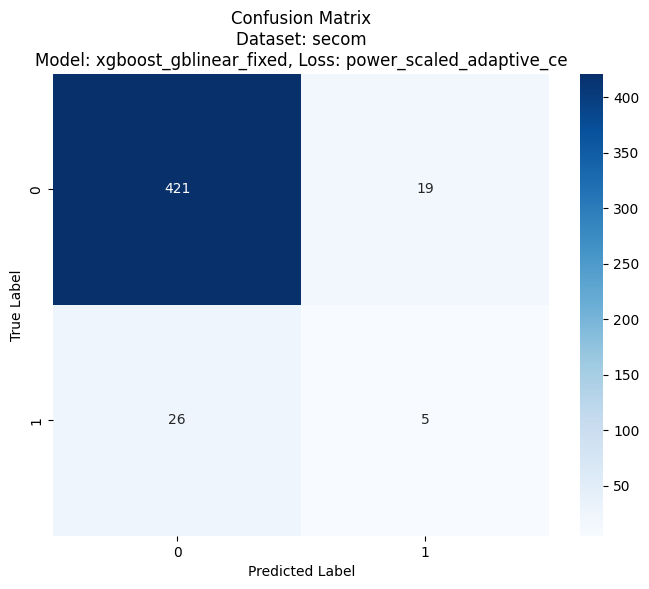

✅ power_scaled_adaptive_ce 완료 - F1: 0.1818

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_secom_alpha_only.csv

Processing Dataset: credit_card_default


[I 2025-11-12 08:37:50,050] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


Data loaded. Train shape: (21000, 33), Test shape: (9000, 33)
Number of classes (raw): 2. Multi-class problem: False
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 347, 'learning_rate': 0.154438834516908, 'reg_alpha': 2.0456768806366122e-05, 'reg_lambda': 1.5582033754652484e-08}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 347, 'learning_rate': 0.154438834516908, 'reg_alpha': 2.0456768806366122e-05, 'reg_lambda': 1.5582033754652484e-08}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:37:53,938] Trial 0 finished with value: 0.6872427607673677 and parameters: {'loss_power_alpha': 3.17520495964358}. Best is trial 0 with value: 0.6872427607673677.
[I 2025-11-12 08:37:56,339] Trial 1 finished with value: 0.6807601020549315 and parameters: {'loss_power_alpha': 2.332026854021459}. Best is trial 0 with value: 0.6872427607673677.
[I 2025-11-12 08:37:58,462] Trial 2 finished with value: 0.6585351543578496 and parameters: {'loss_power_alpha': 1.012726795575003}. Best is trial 0 with value: 0.6872427607673677.
[I 2025-11-12 08:38:00,580] Trial 3 finished with value: 0.6813949519143822 and parameters: {'loss_power_alpha': 2.3901348836799037}. Best is trial 0 with value: 0.6872427607673677.
[I 2025-11-12 08:38:02,623] Trial 4 finished with value: 0.6854537103878253 and parameters: {'loss_power_alpha': 2.9459695079214443}. Best is trial 0 with value: 0.6872427607673677.
[I 2025-11-12 08:38:05,057] Trial 5 finished with value: 0.6825577863479722 and parameters: {'

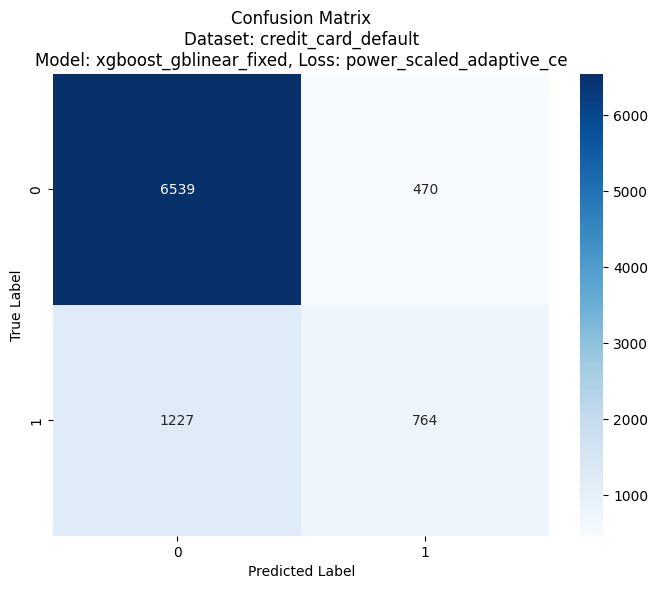

[I 2025-11-12 08:39:30,894] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


✅ power_scaled_adaptive_ce 완료 - F1: 0.4738

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_credit_card_default_alpha_only.csv

Processing Dataset: glass
Data loaded. Train shape: (149, 9), Test shape: (65, 9)
Number of classes (raw): 7. Multi-class problem: True
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 302, 'learning_rate': 0.29878262985446585, 'reg_alpha': 1.7165743994701085e-08, 'reg_lambda': 0.0016194978636476455}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 302, 'learning_rate': 0.29878262985446585, 'reg_alpha': 1.7165743994701085e-08, 'reg_lambda': 0.0016194978636476455}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:39:31,535] Trial 0 finished with value: 0.6052706587810952 and parameters: {'loss_power_alpha': 2.3034563393559027}. Best is trial 0 with value: 0.6052706587810952.
[I 2025-11-12 08:39:32,090] Trial 1 finished with value: 0.5856091936737098 and parameters: {'loss_power_alpha': 2.929850492116507}. Best is trial 0 with value: 0.6052706587810952.
[I 2025-11-12 08:39:32,684] Trial 2 finished with value: 0.558471635043643 and parameters: {'loss_power_alpha': 3.234989245572337}. Best is trial 0 with value: 0.6052706587810952.
[I 2025-11-12 08:39:33,253] Trial 3 finished with value: 0.6343926064514299 and parameters: {'loss_power_alpha': 1.456174277896738}. Best is trial 3 with value: 0.6343926064514299.
[I 2025-11-12 08:39:33,842] Trial 4 finished with value: 0.5492469162403802 and parameters: {'loss_power_alpha': 3.3071420107385685}. Best is trial 3 with value: 0.6343926064514299.
[I 2025-11-12 08:39:34,405] Trial 5 finished with value: 0.5856091936737098 and parameters: {'

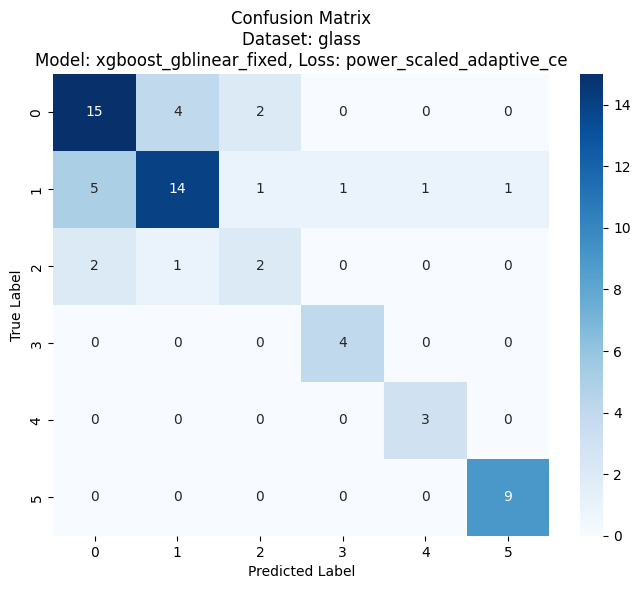

[I 2025-11-12 08:39:59,489] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


✅ power_scaled_adaptive_ce 완료 - F1: 0.7430

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_glass_alpha_only.csv

Processing Dataset: steel_faults
Data loaded. Train shape: (1358, 27), Test shape: (583, 27)
Number of classes (raw): 7. Multi-class problem: True
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 334, 'learning_rate': 0.2799055935493331, 'reg_alpha': 1.1637351180741832e-05, 'reg_lambda': 0.00011569576159139148}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 334, 'learning_rate': 0.2799055935493331, 'reg_alpha': 1.1637351180741832e-05, 'reg_lambda': 0.00011569576159139148}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:40:01,372] Trial 0 finished with value: 0.7335709132933458 and parameters: {'loss_power_alpha': 1.9265971438201828}. Best is trial 0 with value: 0.7335709132933458.
[I 2025-11-12 08:40:05,321] Trial 1 finished with value: 0.7406827327479008 and parameters: {'loss_power_alpha': 1.638630352363685}. Best is trial 1 with value: 0.7406827327479008.
[I 2025-11-12 08:40:07,032] Trial 2 finished with value: 0.7469336438249149 and parameters: {'loss_power_alpha': 1.386569923849818}. Best is trial 2 with value: 0.7469336438249149.
[I 2025-11-12 08:40:08,724] Trial 3 finished with value: 0.7028909158894298 and parameters: {'loss_power_alpha': 3.119125790038713}. Best is trial 2 with value: 0.7469336438249149.
[I 2025-11-12 08:40:10,437] Trial 4 finished with value: 0.7352696467194594 and parameters: {'loss_power_alpha': 1.8607255824298603}. Best is trial 2 with value: 0.7469336438249149.
[I 2025-11-12 08:40:12,211] Trial 5 finished with value: 0.7188643240287608 and parameters: {

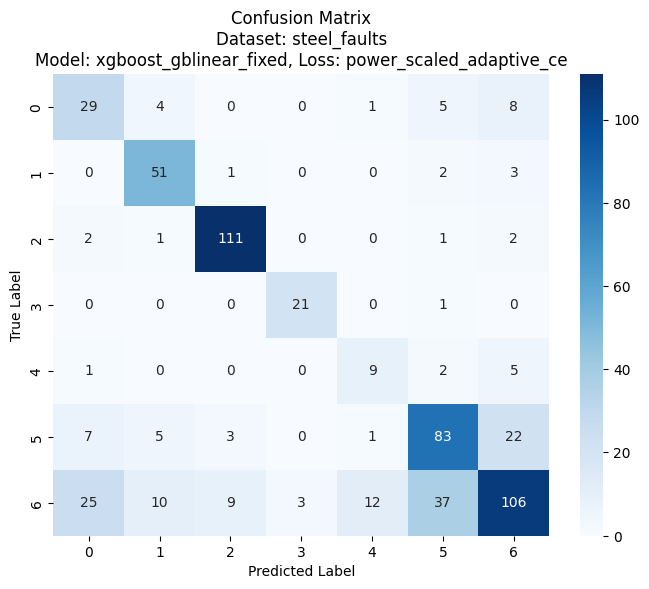

[I 2025-11-12 08:41:24,158] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


✅ power_scaled_adaptive_ce 완료 - F1: 0.6959

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_steel_faults_alpha_only.csv

Processing Dataset: yeast
Data loaded. Train shape: (1038, 8), Test shape: (446, 8)
Number of classes (raw): 10. Multi-class problem: True
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 396, 'learning_rate': 0.13682844418801213, 'reg_alpha': 2.72733154713787e-08, 'reg_lambda': 0.001454886551845638}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 396, 'learning_rate': 0.13682844418801213, 'reg_alpha': 2.72733154713787e-08, 'reg_lambda': 0.001454886551845638}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:41:25,725] Trial 0 finished with value: 0.5307586809862049 and parameters: {'loss_power_alpha': 3.4876942584302726}. Best is trial 0 with value: 0.5307586809862049.
[I 2025-11-12 08:41:27,237] Trial 1 finished with value: 0.5471542729445903 and parameters: {'loss_power_alpha': 2.608158693674646}. Best is trial 1 with value: 0.5471542729445903.
[I 2025-11-12 08:41:28,726] Trial 2 finished with value: 0.537638030518138 and parameters: {'loss_power_alpha': 2.8130050311864947}. Best is trial 1 with value: 0.5471542729445903.
[I 2025-11-12 08:41:30,224] Trial 3 finished with value: 0.5698471178475346 and parameters: {'loss_power_alpha': 1.1806841515019615}. Best is trial 3 with value: 0.5698471178475346.
[I 2025-11-12 08:41:31,713] Trial 4 finished with value: 0.5648324478978628 and parameters: {'loss_power_alpha': 1.5944191670954482}. Best is trial 3 with value: 0.5698471178475346.
[I 2025-11-12 08:41:33,935] Trial 5 finished with value: 0.5705617101427682 and parameters: 

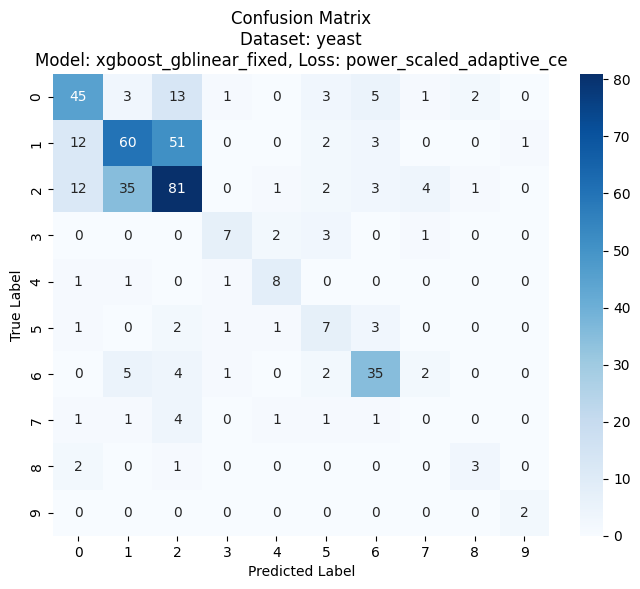

[I 2025-11-12 08:42:36,492] A new study created in memory with name: xgb_linear_power_scaled_adaptive_ce_f1_macro_fixed


✅ power_scaled_adaptive_ce 완료 - F1: 0.5331

💾 중간 결과 저장: /content/drive/MyDrive/imbalanced loss project/f1-score/alpha_tuning/xgb_linear_results_temp_yeast_alpha_only.csv

Processing Dataset: page_blocks
Data loaded. Train shape: (3831, 10), Test shape: (1642, 10)
Number of classes (raw): 5. Multi-class problem: True
🔧 Using Fixed Model Params: {'booster': 'gblinear', 'n_estimators': 401, 'learning_rate': 0.23442342073496353, 'reg_alpha': 1.590737014937549e-06, 'reg_lambda': 4.966750393226984e-06}

------------------------------------------------------------
Optimizing LOSS PARAMS for: power_scaled_adaptive_ce
------------------------------------------------------------

Optuna 하이퍼파라미터 최적화 시작
모델: XGBoost gblinear (선형 모델)
손실 함수: power_scaled_adaptive_ce
평가 지표: f1_macro
시행 횟수: 40
고정 파라미터 사용: {'booster': 'gblinear', 'n_estimators': 401, 'learning_rate': 0.23442342073496353, 'reg_alpha': 1.590737014937549e-06, 'reg_lambda': 4.966750393226984e-06}



  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-11-12 08:42:40,735] Trial 0 finished with value: 0.32190280315973546 and parameters: {'loss_power_alpha': 3.224197498489257}. Best is trial 0 with value: 0.32190280315973546.
[I 2025-11-12 08:42:42,932] Trial 1 finished with value: 0.5800636715277835 and parameters: {'loss_power_alpha': 1.0008916043546603}. Best is trial 1 with value: 0.5800636715277835.
[I 2025-11-12 08:42:45,072] Trial 2 finished with value: 0.5328440379424225 and parameters: {'loss_power_alpha': 3.039766806856838}. Best is trial 1 with value: 0.5800636715277835.
[I 2025-11-12 08:42:47,145] Trial 3 finished with value: 0.5330172758740199 and parameters: {'loss_power_alpha': 2.7525699994535597}. Best is trial 1 with value: 0.5800636715277835.
[I 2025-11-12 08:42:49,219] Trial 4 finished with value: 0.5263977392604237 and parameters: {'loss_power_alpha': 1.456300303269255}. Best is trial 1 with value: 0.5800636715277835.
[I 2025-11-12 08:42:52,133] Trial 5 finished with value: 0.5251658937629665 and parameters:

In [ ]:
# 4번셀: (수정본) XGBoost gblinear + 'Alpha-Only' 최적화

import optuna_tuner_alpha_only
importlib.reload(optuna_tuner_alpha_only) # 수정된 튜너 강제 새로고침
import pandas as pd
import numpy as np
from scipy.special import expit, softmax
import json
import evaluation # evaluation 모듈 임포트 확인
import data_handler # data_handler 모듈 임포트 확인

# --- 1. [신규] 최적화된 기본 파라미터 로드 ---
# (이전 100-trial 실험에서 얻은 JSON 파일)
base_params_path = os.path.join(results_path, 'optimized_parameters_xgb_linear.json')
try:
    with open(base_params_path, 'r') as f:
        base_optimized_params = json.load(f)
    print(f"✅ 'optimized_parameters_xgb_linear.json'에서 기본 파라미터를 로드했습니다.")
except Exception as e:
    print(f"❌ JSON 파일 로드 실패: {e}. 기본값을 사용합니다.")
    base_optimized_params = {}
# -----------------------------------------------

all_results = []
optimized_params_alpha_only = {} # 새 결과 저장용

# Optuna 설정
OPTUNA_CONFIG = {
    'n_trials': 40,         # Alpha만 튜닝하므로 30회
    'cv_folds': 3,
    'metric': 'f1_macro',
}

# (datasets_to_run 리스트는 2번 셀에서 정의되었다고 가정)

for dataset_name in datasets_to_run:
    print(f"\n{'='*80}")
    print(f"Processing Dataset: {dataset_name}")
    print(f"{'='*80}")

    X_train, X_test, y_train, y_test = data_handler.load_dataset(
        dataset_name=dataset_name, base_data_path=data_path, random_state=42
    )

    # (데이터 로드 및 n_classes 설정 부분)
    unique_classes = y_train.unique()
    is_multiclass = len(unique_classes) > 2
    if is_multiclass:
        n_classes = int(y_train.max() + 1)
    else:
        n_classes = len(unique_classes)
    print(f"Data loaded. Train shape: {X_train.shape}, Test shape: {X_test.shape}")
    print(f"Number of classes (raw): {n_classes}. Multi-class problem: {is_multiclass}")

    if hasattr(X_train, 'values'):
        X_train_np = X_train.values
        X_test_np = X_test.values
    else:
        X_train_np = X_train
        X_test_np = X_test

    # --- 2. [신규] 고정할 기본 파라미터 추출 ---
    # Standard CE의 최적 파라미터를 기본값으로 사용 (가장 중립적)
    base_param_key = f"{dataset_name}_standard_ce"
    if base_param_key not in base_optimized_params:
        print(f"⚠️ {base_param_key}에 대한 파라미터 없음. 임시 기본값 사용.")
        # (임시 기본값)
        FIXED_MODEL_PARAMS = {
            'booster': 'gblinear', 'n_estimators': 100, 'learning_rate': 0.1,
            'reg_alpha': 1e-5, 'reg_lambda': 1.0,
        }
    else:
        # JSON에서 모델 파라미터만 추출
        base_params = base_optimized_params[base_param_key]['params']
        FIXED_MODEL_PARAMS = {
            'booster': 'gblinear', # 고정
            'n_estimators': base_params.get('n_estimators', 100),
            'learning_rate': base_params.get('learning_rate', 0.1),
            'reg_alpha': base_params.get('reg_alpha', 1e-5),
            'reg_lambda': base_params.get('reg_lambda', 1.0),
        }
    print(f"🔧 Using Fixed Model Params: {FIXED_MODEL_PARAMS}")
    # -----------------------------------------------

    # 튜닝할 손실 함수 리스트 (파라미터가 있는 것들)
    loss_names = [
        'power_scaled_adaptive_ce' # PLWCE (alpha 튜닝)
        #'power_scaled_inv_ce',      # PS-WCE (alpha 튜닝)
        #'focal_loss',               # Focal (gamma 튜닝)
        #'class_balanced_ce',        # CB (beta 튜닝)
    ]

    for loss_name in loss_names:
        print(f"\n{'-'*60}")
        print(f"Optimizing LOSS PARAMS for: {loss_name}")
        print(f"{'-'*60}")

        tuner = optuna_tuner_alpha_only.OptunaHyperparameterTuner(
            n_trials=OPTUNA_CONFIG['n_trials'],
            cv_folds=OPTUNA_CONFIG['cv_folds'],
            random_state=42,
            direction='maximize',
            metric=OPTUNA_CONFIG['metric']
        )

        try:
            # --- [수정] optimize 함수에 fixed_model_params 전달 ---
            best_params = tuner.optimize(
                X_train_np, y_train,
                loss_name=loss_name,
                fixed_model_params=FIXED_MODEL_PARAMS, # 고정 파라미터 전달
                show_progress_bar=True
            )
            # ----------------------------------------------------

            param_key = f"{dataset_name}_{loss_name}"
            optimized_params_alpha_only[param_key] = { # 새 딕셔너리에 저장
                'params': best_params,
                'score': tuner.best_score
            }

            model = tuner.get_best_model(X_train_np, y_train, loss_name=loss_name)

            # (평가 부분은 기존 코드와 동일)
            n_classes_for_eval = model.n_classes_actual_
            y_test_encoded = model.label_encoder_.transform(y_test)

            y_pred_raw = model.predict(X_test_np, output_margin=True)

            if is_multiclass:
                if loss_name == 'standard_ce':
                    y_pred_proba = model.predict_proba(X_test_np)
                else:
                    y_pred_proba = softmax(y_pred_raw.reshape(-1, n_classes_for_eval), axis=1)
            else:
                if loss_name == 'standard_ce':
                    y_pred_proba = model.predict_proba(X_test_np)[:, 1]
                else:
                    y_pred_proba = expit(y_pred_raw)

            metrics = evaluation.evaluate_classification_model(
                y_true=y_test_encoded,
                y_pred_proba=y_pred_proba,
                n_classes=n_classes_for_eval,
                model_name='xgboost_gblinear_fixed', # 모델 이름 변경
                loss_name=loss_name,
                dataset_name=dataset_name,
                save_path=results_path
            )
            all_results.append(metrics)

            print(f"✅ {loss_name} 완료 - F1: {metrics['F1-Score']:.4f}")

        except Exception as e:
            print(f"❌ Error optimizing {loss_name}: {e}")
            import traceback
            traceback.print_exc()
            continue

    # (중간 저장 부분은 기존과 동일)
    temp_results_df = pd.DataFrame(all_results)
    temp_csv_path = os.path.join(results_path, f'xgb_linear_results_temp_{dataset_name}_alpha_only.csv')
    temp_results_df.to_csv(temp_csv_path, index=False)
    print(f"\n💾 중간 결과 저장: {temp_csv_path}")

# --- [수정] 새 파일 이름으로 저장 ---
params_save_path = os.path.join(results_path, 'optimized_parameters_xgb_linear_ALPHA_ONLY.json')
with open(params_save_path, 'w') as f:
    json.dump(optimized_params_alpha_only, f, indent=2)
print(f"\n✅ [Alpha 튜닝] 최적화된 파라미터가 '{params_save_path}'에 저장되었습니다.")

results_df = pd.DataFrame(all_results)
results_df['PR_AUC'] = results_df['PR_AUC'].replace(['N/A', -1], np.nan)

column_order = ['Dataset', 'Model', 'Loss', 'F1-Score', 'ROC_AUC', 'PR_AUC',
                'Accuracy', 'Precision', 'Recall']
# (컬럼 순서 적용)
results_df = results_df[column_order]
sorted_results_df = results_df.sort_values(by=['Dataset', 'F1-Score'], ascending=[True, False])

output_csv_path = os.path.join(results_path, 'xgboost_gblinear_full_results_ALPHA_ONLY.csv')
sorted_results_df.to_csv(output_csv_path, index=False)

print("="*80)
print("      XGBoost gblinear (Alpha 튜닝) 최적화 완료")
print("="*80)
print(f"📊 전체 결과: {output_csv_path}")
print(f"⚙️ 최적 파라미터: {params_save_path}")